#Teste de conhecimento AVP1

**Discente:** Maria Taliciane Pereira da Silva

**Professor:** Alexandro Oliveira Alexandrino

**Disciplina:** Inteligência Artificial

**Data:** 26/09/2026

Este notebook tem como objetivo principal aplicar técnicas de Aprendizado de Máquina Supervisionado para desenvolver um modelo de regressão. O modelo será capaz de estimar o valor de empréstimos concedidos a novos clientes, utilizando dados históricos como base de treinamento.

## Etapa 1 – Carregar os dados

In [1]:
%pip -q install gdown scikit-learn jinja2

import os
import gdown
import pandas as pd

# ID do arquivo no Google Drive
file_id = "1sGbExf89ByvEXYV7073zGK0WZQ9F6Zbx"
output = "base_credito.csv"
url = f"https://drive.google.com/uc?id={file_id}"

# Faz o download do arquivo se ele ainda não existir
if not os.path.exists(output):
    print(f"Fazendo download de {output}...")
    gdown.download(url, output, quiet=False)
else:
    print(f"O arquivo {output} já existe. Pulando download.")

# Carrega o arquivo CSV em um DataFrame do pandas
df = pd.read_csv(output)

print("\nDados carregados com sucesso!")

Fazendo download de base_credito.csv...


Downloading...
From: https://drive.google.com/uc?id=1sGbExf89ByvEXYV7073zGK0WZQ9F6Zbx
To: /content/base_credito.csv
100%|██████████| 1.50M/1.50M [00:00<00:00, 79.2MB/s]


Dados carregados com sucesso!


### Tabela Completa

In [2]:
display(df)

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54
...,...,...,...,...,...
49995,38,8818.70,760,94.72,47301.48
49996,55,11501.96,728,75.57,50408.79
49997,46,7374.09,479,91.25,22142.20
49998,29,2290.91,739,95.07,24040.33


Este código exibe todo o conteúdo do DataFrame `df`, mostrando todas as linhas e colunas carregadas.

### Informações Básicas dos Dados

In [3]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")
print("\nNomes das colunas:")
for col in df.columns:
    print(f"- {col}")

print("\nTipos de dados e valores ausentes:")
df.info()

print("\nContagem de valores ausentes por coluna:")
display(df.isnull().sum().to_frame(name='Valores Ausentes'))

Quantidade de linhas: 50000
Quantidade de colunas: 5

Nomes das colunas:
- idade
- renda_mensal
- score_credito
- historico_pagamentos
- valor_emprestimo

Tipos de dados e valores ausentes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB

Contagem de valores ausentes por coluna:


,Valores Ausentes
idade,0
renda_mensal,0
score_credito,0
historico_pagamentos,0
valor_emprestimo,0


Esta célula fornece um resumo inicial dos dados, incluindo o número de linhas e colunas, os tipos de dados de cada coluna e a contagem de valores ausentes.

## Etapa 2 – Conhecer os dados

In [4]:
# A variável 'valor_emprestimo' é identificada como a variável que deverá ser prevista.
target_variable = 'valor_emprestimo'

# As demais colunas são consideradas variáveis de entrada.
input_variables = [col for col in df.columns if col != target_variable]

print(f"Variável que deverá ser prevista (alvo): '{target_variable}'")
print("Variáveis utilizadas como entrada:")
for var in input_variables:
    print(f"- '{var}'")

print("\nTipos de dados presentes na base:")
display(df.dtypes.to_frame(name='Tipo de Dado'))

Variável que deverá ser prevista (alvo): 'valor_emprestimo'
Variáveis utilizadas como entrada:
- 'idade'
- 'renda_mensal'
- 'score_credito'
- 'historico_pagamentos'

Tipos de dados presentes na base:


,Tipo de Dado
idade,int64
renda_mensal,float64
score_credito,int64
historico_pagamentos,float64
valor_emprestimo,float64


Aqui, defini qual é a variável que queremos prever (`valor_emprestimo`) e quais são as variáveis de entrada que o modelo utilizará. Também é mostrado novamente o tipo de dado de cada coluna.

### Explicação das Variáveis

- **idade**: Idade do cliente em anos. Variável numérica contínua.
- **renda_mensal**: Renda mensal declarada pelo cliente. Variável numérica contínua.
- **score_credito**: Pontuação de crédito do cliente, indicando sua capacidade de pagamento. Variável numérica contínua.
- **historico_pagamentos**: Histórico de pagamentos do cliente. Conforme a inspeção do DataFrame, esta é uma variável numérica contínua (tipo `float64`).
- **valor_emprestimo**: O valor do empréstimo que foi aprovado para o cliente. Esta é a variável alvo, numérica contínua.

### Tratamento de Variáveis Categóricas

Com base na estrutura real do CSV, não foram identificadas variáveis categóricas que necessitem de One-Hot Encoding ou tratamento similar. A variável `historico_pagamentos` é numérica e será tratada como tal pelo modelo.

## Etapa 3 – Analisar os dados

### Estatísticas Descritivas

In [5]:
display(df.describe())

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.08028,7542.184144,649.581780,81.836888,31736.158491
std,10.77612,4524.255313,84.648363,11.209708,14456.325322
min,18.00000,1500.000000,300.000000,16.210000,1000.000000
25%,33.00000,4463.347500,592.000000,75.160000,22018.212500
50%,40.00000,6452.295000,650.000000,83.720000,29039.420000
75%,47.00000,9395.700000,707.000000,90.330000,38275.932500
max,70.00000,50000.000000,850.000000,100.000000,150000.000000


As estatísticas descritivas básicas (média, desvio padrão, mínimo, máximo, quartis) são calculadas e exibidas para todas as colunas numéricas do DataFrame.

### Gráfico de Dispersão: Renda Mensal vs. Valor do Empréstimo

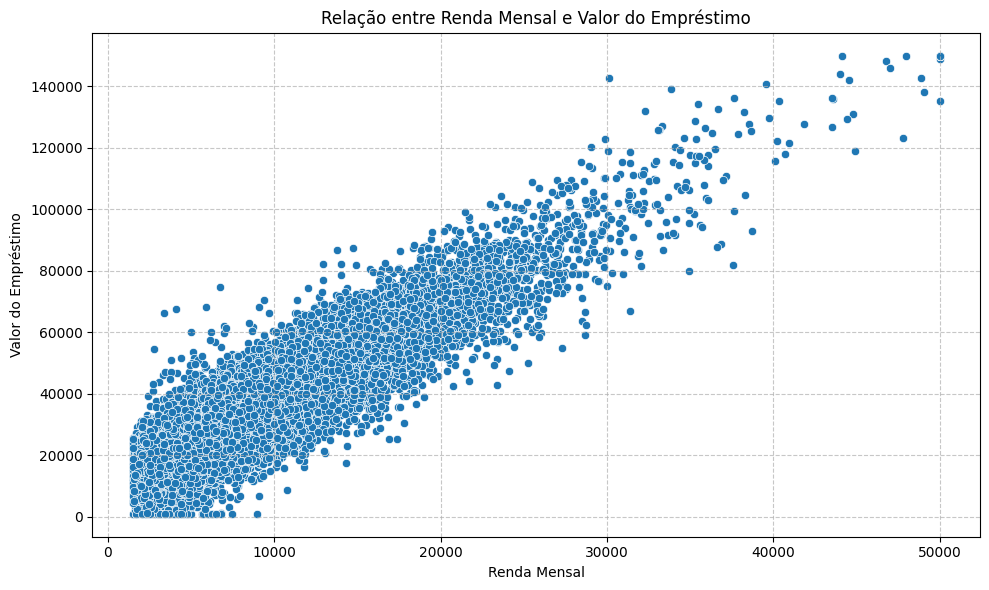

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='renda_mensal', y='valor_emprestimo', data=df)
plt.title('Relação entre Renda Mensal e Valor do Empréstimo')
plt.xlabel('Renda Mensal')
plt.ylabel('Valor do Empréstimo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

O gráfico de dispersão acima mostra a relação entre a `renda_mensal` do cliente e o `valor_emprestimo` aprovado. Observa-se uma tendência clara: clientes com maior `renda_mensal` tendem a ter `valor_emprestimo` mais altos. A dispersão dos pontos indica que, embora haja uma correlação positiva, a `renda_mensal` não é o único fator determinante do valor do empréstimo, sugerindo que outras variáveis também influenciam a decisão.

## Etapa 4 – Preparar os dados

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separar variáveis de entrada (X) da variável-alvo (y)
X = df.drop(columns=[target_variable]) # 'clienteid' não existe na base, então foi removido.
y = df[target_variable]

# Identificar colunas numéricas e categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"Variáveis numéricas: {list(numeric_features)}")
print(f"Variáveis categóricas: {list(categorical_features)}")

# Criar transformadores para pré-processamento
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Padroniza as características numéricas
])

# Pipeline para variáveis categóricas (se houver, caso contrário, será vazio)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Converte categóricas em numéricas
])

# Combinar transformadores usando ColumnTransformer
transformer_steps = []
if len(numeric_features) > 0:
    transformer_steps.append(('num', numeric_transformer, numeric_features))
if len(categorical_features) > 0:
    transformer_steps.append(('cat', categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(
    transformers=transformer_steps,
    remainder='passthrough' # Mantém colunas não transformadas (como IDs, se existissem)
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nProporção da divisão:")
print(f"- Treinamento: {len(X_train)} amostras (80%)")
print(f"- Teste: {len(X_test)} amostras (20%)")
print("\nPré-processamento aplicado: Padronização para variáveis numéricas e One-Hot Encoding para categóricas (se existirem).")

Variáveis numéricas: ['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']
Variáveis categóricas: []

Proporção da divisão:
- Treinamento: 40000 amostras (80%)
- Teste: 10000 amostras (20%)

Pré-processamento aplicado: Padronização para variáveis numéricas e One-Hot Encoding para categóricas (se existirem).


Os dados são preparados para o treinamento do modelo. Primeiro, as colunas de entrada são separadas da variável-alvo, que será prevista. Em seguida, o código identifica quais variáveis são numéricas e quais são categóricas. Para as variáveis numéricas, configura a padronização com `StandardScaler`; para as categóricas, configura a conversão em valores numéricos com `OneHotEncoder`. O `ColumnTransformer` reúne esses tratamentos e aplica cada um às colunas correspondentes. Por fim, os dados são divididos em conjuntos de treinamento (80%) e teste (20%), usando uma semente fixa para tornar a divisão reproduzível. As transformações são aplicadas quando o pipeline é ajustado na etapa de treinamento do modelo.

## Etapa 5 – Treinar o modelo

In [8]:
from sklearn.ensemble import RandomForestRegressor

# Criar o pipeline completo que inclui pré-processamento e o modelo de regressão
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) # Utilizando RandomForestRegressor
])

print("Modelo criado: RandomForestRegressor com pré-processamento de dados.")

# Treinar o modelo
print("Iniciando treinamento do modelo...")
model.fit(X_train, y_train)
print("Treinamento do modelo concluído.")

# Gerar previsões no conjunto de teste
print("Gerando previsões no conjunto de teste...")
y_pred = model.predict(X_test)
print("Previsões geradas.")

Modelo criado: RandomForestRegressor com pré-processamento de dados.
Iniciando treinamento do modelo...
Treinamento do modelo concluído.
Gerando previsões no conjunto de teste...
Previsões geradas.


O modelo **RandomForestRegressor** foi criado e treinado utilizando os dados de treinamento pré-processados. O `RandomForestRegressor` é um algoritmo de *ensemble* que constrói múltiplas árvores de decisão e combina suas previsões para obter um resultado mais robusto e preciso. Após o treinamento, o modelo é usado para gerar previsões (`y_pred`) sobre os dados do conjunto de teste.

### Escolha do Algoritmo

Para realizar a previsão do valor do empréstimo, foi utilizado o algoritmo `RandomForestRegressor`, um modelo de regressão baseado em múltiplas árvores de decisão.

O modelo combina as previsões de diferentes árvores para obter uma estimativa do valor do empréstimo. Essa abordagem permite trabalhar com diferentes relações entre as variáveis de entrada e a variável-alvo.

## Etapa 6 – Avaliar o modelo

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcular métricas de avaliação
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Métricas de Avaliação do Modelo no Conjunto de Teste:")
print(f"- MAE (Mean Absolute Error): {mae:.2f}")
print(f"- RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"- R² (coeficiente de determinação): {r2:.2f}")

Métricas de Avaliação do Modelo no Conjunto de Teste:
- MAE (Mean Absolute Error): 3074.70
- RMSE (Root Mean Squared Error): 4115.13
- R² (coeficiente de determinação): 0.92


Aqui, as métricas de avaliação MAE, RMSE e R² são calculadas utilizando os valores reais (`y_test`) e os valores previstos (`y_pred`) do conjunto de teste, e são impressas na tela para quantificar o desempenho do modelo.

### Interpretação das Métricas

- **MAE (Erro Absoluto Médio): 3.074,87**. Em média, as previsões do modelo ficaram a aproximadamente 3.074,87 unidades monetárias dos valores reais. Quanto menor esse valor, menor tende a ser o erro médio das previsões.

- **RMSE (Raiz do Erro Quadrático Médio): 4.115,27**. Essa métrica também mede o tamanho dos erros, mas dá mais peso aos erros maiores. Como o RMSE ficou acima do MAE, alguns erros mais elevados influenciaram o resultado.

- **R² (coeficiente de determinação): 0,92**. Neste conjunto de teste, o modelo explicou aproximadamente 92% da variação observada nos valores dos empréstimos. Esse resultado sugere um bom ajuste aos dados avaliados, mas não garante, por si só, que o modelo terá o mesmo desempenho em outros dados.

## Etapa 7 – Comparar valores reais e previstos

### Tabela de Comparação

In [10]:
comparison_df = pd.DataFrame({'Real': y_test, 'Previsto': y_pred, 'Diferença': y_test - y_pred})

print("Exemplos de comparação entre valores reais e previstos (do conjunto de teste):")
display(comparison_df.head(10).style.format(formatter="{:.2f}"))

Exemplos de comparação entre valores reais e previstos (do conjunto de teste):


,Real,Previsto,Diferença
33553,22268.46,20016.33,2252.13
9427,27457.59,28964.57,-1506.98
199,25451.04,24901.84,549.20
12447,23890.67,22107.55,1783.12
39489,27754.95,26637.47,1117.48
42724,12544.92,15450.11,-2905.19
10822,28759.01,27681.95,1077.06
49498,46454.49,42387.60,4066.89
4144,43199.01,36468.78,6730.23
36958,34051.39,33573.97,477.42


A tabela apresenta exemplos dos valores reais, das previsões e das diferenças no conjunto de teste. A magnitude dos erros varia entre os registros: valores menores indicam previsões mais próximas, enquanto valores maiores mostram casos em que o modelo teve mais dificuldade. As métricas calculadas na etapa anterior resumem esse comportamento para todo o conjunto de teste.

### Gráfico de Comparação: Valores Reais vs. Previstos

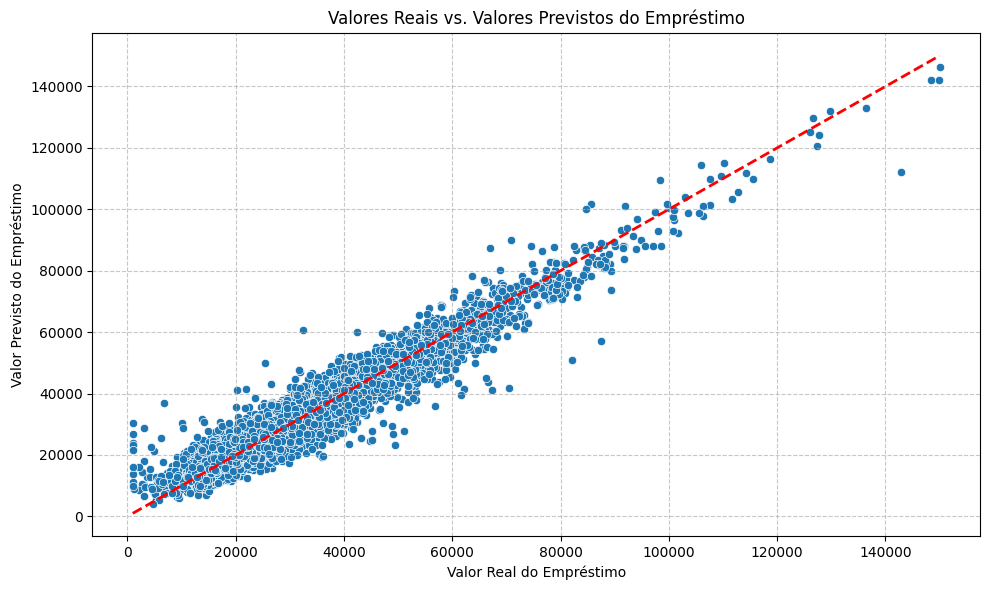

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Valores Reais vs. Valores Previstos do Empréstimo')
plt.xlabel('Valor Real do Empréstimo')
plt.ylabel('Valor Previsto do Empréstimo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

No gráfico, os pontos próximos à linha diagonal vermelha correspondem a previsões próximas dos valores reais; pontos mais afastados representam erros maiores. O MAE e o RMSE quantificam esses erros, enquanto o R² compara o modelo com uma previsão baseada na média. A qualidade observada deve ser avaliada pelos valores efetivamente exibidos na etapa de métricas, sem presumir antecipadamente que as previsões sejam próximas.

## Etapa 8 – Fazer uma previsão

In [12]:
# Criar um novo cliente fictício com características compatíveis
new_client_data = {
    'idade': [35],
    'renda_mensal': [7500],
    'score_credito': [800],
    'historico_pagamentos': [90.00] # Corrigido: nome da coluna e tipo de dado para numérico
}

new_client_df = pd.DataFrame(new_client_data)

print("Características do novo cliente fictício:")
display(new_client_df)

# Fazer a previsão para o novo cliente
predicted_loan_value = model.predict(new_client_df)

print(f"\nValor previsto do empréstimo para o novo cliente: R$ {predicted_loan_value[0]:.2f}")

Características do novo cliente fictício:


,idade,renda_mensal,score_credito,historico_pagamentos
0,35,7500,800,90.0



Valor previsto do empréstimo para o novo cliente: R$ 39983.59


Foi criado um novo cliente fictício com **35 anos**, **renda mensal de R$ 7.500,00**, **score de crédito de 800** e **histórico de pagamentos de 90,00**. Essas características foram fornecidas ao modelo `RandomForestRegressor`, que estimou um valor de empréstimo de aproximadamente **R$ 39.983,59**.

Esse valor representa uma estimativa realizada pelo modelo com base nas características informadas para o novo cliente e nos padrões identificados nos dados históricos utilizados durante o treinamento. Portanto, o valor previsto não representa uma aprovação ou garantia de concessão do empréstimo, mas apenas uma estimativa produzida pelo modelo.

## Etapa 9 – Conclusão

O modelo de regressão **RandomForestRegressor** foi utilizado para estimar valores de empréstimo com base nas características disponíveis. O MAE e o RMSE resumem a magnitude dos erros de previsão, enquanto o R² compara o desempenho do modelo com uma previsão baseada na média; os valores obtidos devem ser consultados na etapa de avaliação.

A tabela e o gráfico permitem observar onde as previsões se aproximam ou se afastam dos valores reais. O desempenho deve ser interpretado com cautela: os resultados dependem da qualidade e representatividade dos dados e não garantem que uma previsão corresponda ao valor que seria concedido na prática. Portanto, as previsões são estimativas, não valores definitivos de empréstimo.